# Session 6 — Graph Analytics + Model Enrichment
## PageRank · Louvain on **Customer Nodes** · Before/After Metric

**Team:** GraphMinds — Riya · Atharva · Farhan · Sacharith · Shubhendu  
**Course:** Big Data and Business Intelligence Capstone

---

### Key Fix vs Previous Attempt
Previously PageRank ran on **Article nodes** but the classifier predicted **Customer value**.  
That was a node-type mismatch — article scores could not cleanly merge onto customer rows.

This notebook fixes it:  
- PageRank runs on **Customer nodes** via **PURCHASED relationships**
- Louvain runs on **Customer nodes** via **PURCHASED relationships**
- `node_id` = `customerId` on **both** the S5 matrix and the GDS export
- The merge is clean — every customer row finds its matching GDS score

---

### What PageRank Means on Customer Nodes
> A customer has high PageRank if they bought the same products as other high-PageRank customers.  
> High-PageRank customers are the most structurally central buyers in the purchase network.  
> Central buyers are likely High-Value — they purchase popular products that connect many customer segments.

### What Louvain Means on Customer Nodes
> Louvain groups customers who bought similar products together into communities.  
> A community is a cluster of customers with overlapping purchase histories.  
> Community labels may encode purchasing personas (e.g. sportswear buyers, basics buyers).

---

### GDS Workflow
```
Step 1: gds.graph.project   → Customer nodes + PURCHASED edges (UNDIRECTED)
Step 2: gds.pageRank.write  → writes pagerank to each Customer node
Step 3: gds.louvain.write   → writes community to each Customer node
Step 4: gds.graph.drop      → release memory
Step 5: Cypher export       → customerId | pagerank | community → pandas
Step 6: pandas.merge        → join onto S5 matrix on node_id (customerId)
Step 7: Pipeline.fit        → re-train same classifier
Step 8: before/after table  → report the lift
```

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from neo4j import GraphDatabase
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, accuracy_score

print('All imports successful ✓')

All imports successful ✓


## Cell 2 — Neo4j Connection

In [2]:
NEO4J_URI      = 'bolt://localhost:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'instance1'
MODELS_DIR     = Path('C:/Jupyter/abc/models')

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def run(query, params={}):
    with driver.session() as session:
        return session.run(query, params).data()

print('Connected to Neo4j ✓')

Connected to Neo4j ✓


## Cell 3 — Pre-flight Check

Verify graph has data before running any algorithm.

In [3]:
node_count = run('MATCH (n) RETURN COUNT(n) AS count')[0]['count']
rel_count  = run('MATCH ()-[r]->() RETURN COUNT(r) AS count')[0]['count']
cust_count = run('MATCH (c:Customer) RETURN COUNT(c) AS count')[0]['count']
purch_count = run('MATCH ()-[r:PURCHASED]->() RETURN COUNT(r) AS count')[0]['count']

print(f'Total nodes:          {node_count:,}')
print(f'Total relationships:  {rel_count:,}')
print(f'Customer nodes:       {cust_count:,}')
print(f'PURCHASED edges:      {purch_count:,}')

assert cust_count  > 0, 'No Customer nodes — re-run 02_graph_load.ipynb'
assert purch_count > 0, 'No PURCHASED edges — re-run 02_graph_load.ipynb'
print('\nPre-flight passed ✓')

Total nodes:          1,477,796
Total relationships:  9,534,769
Customer nodes:       1,371,980
PURCHASED edges:      9,108,459

Pre-flight passed ✓


## Cell 4 — Project the Customer Graph for GDS

**What we project:**
- **Nodes:** Customer only
- **Relationships:** PURCHASED (Customer → Article → Customer via shared articles)

**Important:** PURCHASED goes Customer → Article, not Customer → Customer directly.  
To connect customers we use a **co-purchase projection** — two customers are connected  
if they both bought the same article. GDS handles this via `UNDIRECTED` orientation.

We project Customer + Article nodes and PURCHASED edges.  
GDS will treat the path Customer→Article←Customer as a customer-customer connection.

In [4]:
# Drop projection if it already exists (idempotent)
try:
    run("CALL gds.graph.drop('customer_graph')")
    print('Existing projection dropped ✓')
except Exception:
    print('No existing projection — continuing ✓')

# Project Customer + Article nodes + PURCHASED edges
# UNDIRECTED so Customer→Article←Customer paths connect customers
result = run("""
CALL gds.graph.project(
  'customer_graph',
  ['Customer', 'Article'],
  {
    PURCHASED: {
      orientation: 'UNDIRECTED'
    }
  }
)
YIELD graphName, nodeCount, relationshipCount
""")

print(f'Graph projected: {result[0]}')
print('customer_graph ready for GDS algorithms ✓')

No existing projection — continuing ✓
Graph projected: {'graphName': 'customer_graph', 'nodeCount': 1477522, 'relationshipCount': 18216918}
customer_graph ready for GDS algorithms ✓


## Cell 5 — Run PageRank on Customer Nodes

**What this measures:**  
How central each customer is in the purchase network.  
A customer with high PageRank bought products that were also bought by other high-PageRank customers.  
These are structurally central buyers — likely High-Value.

**Parameters:**
- `maxIterations: 20` — standard convergence
- `dampingFactor: 0.85` — 85% follow purchase link, 15% teleport
- `writeProperty: 'pagerank'` — written to Customer nodes in live graph

In [5]:
pr_result = run("""
CALL gds.pageRank.write('customer_graph', {
  writeProperty:  'pagerank',
  maxIterations:  20,
  dampingFactor:  0.85
})
YIELD nodePropertiesWritten, ranIterations
""")

print(f'PageRank written: {pr_result[0]}')

# Inspect top 10 customers by PageRank
top_pr = run("""
MATCH (c:Customer)
WHERE c.pagerank IS NOT NULL
RETURN c.customerId AS customerId,
       c.ageBand    AS ageBand,
       c.pagerank   AS pagerank
ORDER BY pagerank DESC
LIMIT 10
""")

df_top_pr = pd.DataFrame(top_pr)
print('\nTop 10 Customers by PageRank:')
print(df_top_pr.to_string(index=False))

PageRank written: {'nodePropertiesWritten': 1477522, 'ranIterations': 20}

Top 10 Customers by PageRank:
                                                      customerId ageBand  pagerank
1df07f916d7f648458702bd0b612caee88f1fb4cd1b660fc79ca0c99d27b1293     20s 25.344818
b8f41c0fca0bdaf8cddc0e38b3f99f08795361be258e038f10594e4495563d0c     30s 17.272703
79dfa40cb6761774c4201b62ee0b45defde89bf7b0258ed88327e7b17afe9df9     30s 15.653429
4de6988c4971cfc0c6910a85a54fa8d6fb11be64b87b98c46b73821d7db07ce7     40s 14.847073
e2e398ce5bd2eb4e4a60611dc33b04abd5196200cc39e6f9f52f1ea2b2d1e620 60_plus 14.690770
40d495f34f78039674b1050d70d1db048ab619c7e6e8316f68be1214b2e7435d 60_plus 14.491452
56b1412c11a4f4c376ff82ebda2e37dc8945a909cd8c84df3360f57aebd24866     40s 14.044587
8e6b0776da2701be4591e5f6c5022442d39b734db9c254cd470af91f1b5bbf44     20s 13.558486
ea9867726673a5d8853f10730857ce9efdc770a5789b225156a17e0434559018     40s 13.453243
a07fbd05aa2131f0cef26ecdd3d07598469e111b685d2c61a57b4fabd2cf7abf 

## Cell 6 — Run Louvain on Customer Nodes

**What this measures:**  
Which customers share similar purchasing patterns.  
Customers in the same community bought overlapping sets of products.  
Communities may represent purchasing personas — e.g. sportswear buyers, basics buyers.

**Parameters:**
- `maxLevels: 10` — hierarchical merging steps
- `tolerance: 0.0001` — stops when improvement drops below this
- `writeProperty: 'community'` — written to Customer nodes in live graph

In [6]:
lou_result = run("""
CALL gds.louvain.write('customer_graph', {
  writeProperty: 'community',
  maxLevels:     10,
  tolerance:     0.0001
})
YIELD nodePropertiesWritten, communityCount, modularity
""")

print(f'Louvain result: {lou_result[0]}')

# Inspect top 10 community sizes
comm_sizes = run("""
MATCH (c:Customer)
WHERE c.community IS NOT NULL
RETURN c.community AS community, COUNT(c) AS size
ORDER BY size DESC
LIMIT 10
""")

df_comm = pd.DataFrame(comm_sizes)
print('\nTop 10 Customer Communities by Size:')
print(df_comm.to_string(index=False))

Louvain result: {'nodePropertiesWritten': 1477522, 'communityCount': 667222, 'modularity': 0.26026455565829415}

Top 10 Customer Communities by Size:
 community   size
    177515 179558
    152587 176914
    271821 173053
    152520  73541
    168220  64595
    180023  44778
    299781  13365
    154187  11061
    284733     59
   1425850     45


## Cell 7 — Inspect Community Profiles

Look inside the top 3 communities to understand what type of customers they contain.  
This is the business interpretation step.

In [7]:
# Get top 3 community IDs
top_communities = [row['community'] for row in comm_sizes[:3]]

for comm_id in top_communities:
    profile = run("""
    MATCH (c:Customer)
    WHERE c.community = $comm_id
    RETURN c.ageBand AS ageBand, COUNT(c) AS count
    ORDER BY count DESC
    LIMIT 5
    """, {'comm_id': comm_id})

    print(f'\nCommunity {comm_id} — age band distribution:')
    for row in profile:
        print(f'  {row["ageBand"]}: {row["count"]:,}')


Community 177515 — age band distribution:
  20s: 83,506
  30s: 28,176
  50s: 27,769
  40s: 20,370
  60_plus: 10,597

Community 152587 — age band distribution:
  20s: 62,314
  50s: 36,826
  30s: 30,087
  40s: 25,469
  60_plus: 18,503

Community 271821 — age band distribution:
  20s: 83,272
  40s: 30,468
  50s: 22,425
  30s: 18,835
  Under_20: 14,223


## Cell 8 — Drop the GDS Projection

In [8]:
run("CALL gds.graph.drop('customer_graph') YIELD graphName")
print('GDS projection dropped — memory released ✓')

GDS projection dropped — memory released ✓


## Cell 9 — Export GDS Features to pandas

One row per **Customer**.  
Columns: `node_id` (= customerId), `pagerank`, `community`.  

**This time node_id matches the S5 matrix index exactly** — both are `customerId`.

In [9]:
export_query = """
MATCH (c:Customer)
WHERE c.pagerank IS NOT NULL
RETURN c.customerId AS node_id,
       c.pagerank   AS pagerank,
       c.community  AS community
"""

with driver.session() as session:
    gds_features = pd.DataFrame(session.run(export_query).data())

print(f'GDS features exported: {len(gds_features):,} customers')
print(f'Columns: {list(gds_features.columns)}')
print(f'\nPageRank stats:')
print(gds_features['pagerank'].describe().round(4))
gds_features.head()

GDS features exported: 1,371,980 customers
Columns: ['node_id', 'pagerank', 'community']

PageRank stats:
count    1.371980e+06
mean     3.722000e-01
std      4.300000e-01
min      1.500000e-01
25%      1.500000e-01
50%      1.850000e-01
75%      4.142000e-01
max      2.534480e+01
Name: pagerank, dtype: float64


,node_id,pagerank,community
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.506818,180023
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.311714,152587
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0.150000,307144
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0.150000,307145
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,0.214257,152587


## Cell 10 — Load S5 Matrix & Merge

**This time the merge is clean:**
- S5 matrix index = `customerId`
- GDS features `node_id` column = `customerId`
- Same entity, same ID → every row finds its match

`how='left'` keeps all customers even if GDS missed any isolated ones.

In [10]:
s5_matrix = pd.read_parquet(MODELS_DIR / 's5_matrix.parquet')
print(f'S5 matrix loaded: {s5_matrix.shape}')
print(f'S5 index name: {s5_matrix.index.name}')

# Reset index so node_id becomes a column for merging
s5_reset = s5_matrix.reset_index()  # node_id becomes a column

# Merge GDS customer features onto S5 matrix
enriched = pd.merge(
    s5_reset,
    gds_features,
    how='left',       # keep ALL S5 rows
    on='node_id'
)

# Fill NaN for any customers GDS missed (isolated nodes)
enriched['pagerank']  = enriched['pagerank'].fillna(0.0)
enriched['community'] = enriched['community'].fillna(-1).astype(int)

# Set node_id back as index
enriched = enriched.set_index('node_id')

# Check merge quality
matched = (enriched['pagerank'] > 0).sum()
total   = len(enriched)
print(f'\nEnriched matrix: {enriched.shape}')
print(f'Customers with pagerank > 0: {matched:,} / {total:,} ({matched/total*100:.1f}%)')
print('New columns added: pagerank, community')

S5 matrix loaded: (1097584, 7)
S5 index name: node_id

Enriched matrix: (1097584, 9)
Customers with pagerank > 0: 1,097,584 / 1,097,584 (100.0%)
New columns added: pagerank, community


## Cell 11 — Re-train Pipeline with Enriched Features

Exact same Pipeline structure as S5.  
`pagerank` added to numerical features.  
`community` added to categorical features (label not number).

In [11]:
# ── Pull labels from Neo4j  ──────────────────
spend_query = """
MATCH (c:Customer)-[r:PURCHASED]->()
WHERE r.yearMonth STARTS WITH '2020'
RETURN c.customerId AS node_id,
       SUM(toFloat(r.price)) AS total_spend_2020
"""
with driver.session() as session:
    df_spend = pd.DataFrame(session.run(spend_query).data())

df_spend['total_spend_2020'] = df_spend['total_spend_2020'].fillna(0.0)
median_spend = df_spend[df_spend['total_spend_2020'] > 0]['total_spend_2020'].median()
df_spend['customer_value'] = df_spend['total_spend_2020'].apply(
    lambda x: 'High-Value' if x > median_spend else 'Low-Value'
)
label_map = df_spend.set_index('node_id')['customer_value']
print(f"Labels loaded:  {len(label_map):,}")
print(label_map.value_counts())

# ── Reload parquet + merge + attach labels ─────────────────────────────────────
s5_matrix = pd.read_parquet(MODELS_DIR / 's5_matrix.parquet')

enriched = pd.merge(
    s5_matrix.reset_index(),
    gds_features,
    how='left',
    on='node_id'
)
enriched['pagerank']       = enriched['pagerank'].fillna(0.0)
enriched['community']      = enriched['community'].fillna(-1).astype(int)
enriched['customer_value'] = enriched['node_id'].map(label_map)

print(f"\nEnriched shape:       {enriched.shape}")
print(f"customer_value nulls: {enriched['customer_value'].isna().sum():,}")
print(enriched['customer_value'].value_counts())

# ── Drop null targets, build features, split, train ───────────────────────────
enriched_clean = enriched.dropna(subset=['customer_value'])
print(f"\nRows dropped:    {len(enriched) - len(enriched_clean):,}")
print(f"Rows remaining:  {len(enriched_clean):,}")

numerical_features_e   = ['purchase_degree', 'purchase_degree_2020',
                           'sections_visited', 'age', 'pagerank']
categorical_features_e = ['ageBand', 'memberStatus', 'community']

X_enriched = enriched_clean[numerical_features_e + categorical_features_e].copy()
y_enriched  = enriched_clean['customer_value']
X_enriched.index = enriched_clean.index
X_enriched['community'] = X_enriched['community'].astype(str)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enriched, y_enriched,
    test_size=0.2, random_state=42, stratify=y_enriched
)
print(f'\nEnriched train: {len(X_train_e):,}  |  test: {len(X_test_e):,}')

preprocessor_e = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                       numerical_features_e),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_e)
])
pipeline_e = Pipeline(steps=[
    ('preprocessor', preprocessor_e),
    ('classifier',   RandomForestClassifier(
                         n_estimators=200,
                         class_weight='balanced',
                         random_state=42,
                         n_jobs=1))
])
pipeline_e.fit(X_train_e, y_train_e)
print('Enriched model trained ✓')

Labels loaded:  422,621
customer_value
Low-Value     211311
High-Value    211310
Name: count, dtype: int64

Enriched shape:       (1097584, 10)
customer_value nulls: 759,595
customer_value
High-Value    169048
Low-Value     168941
Name: count, dtype: int64

Rows dropped:    759,595
Rows remaining:  337,989

Enriched train: 270,391  |  test: 67,598
Enriched model trained ✓


## Cell 12 — Before / After Metric Table

> **This is the headline of your Final Presentation graph-analytics slide.**

In [13]:
# Rebuild S5 test set
numerical_s5   = ['purchase_degree', 'purchase_degree_2020', 'sections_visited', 'age']
categorical_s5 = ['ageBand', 'memberStatus']

# Load S5 baseline model
pipeline_s5 = joblib.load(MODELS_DIR / 'customer_value_classifier.pkl')

X_s5 = s5_matrix[numerical_s5 + categorical_s5].copy()
y_s5 = s5_matrix.index.map(label_map)

# Drop rows where label didn't map
valid_mask = y_s5.notna()
X_s5 = X_s5[valid_mask]
y_s5 = y_s5[valid_mask]

print(f"S5 rows after label filter: {len(X_s5):,}")
print(y_s5.value_counts())

_, X_test_s5, _, y_test_s5 = train_test_split(
    X_s5, y_s5, test_size=0.2, random_state=42, stratify=y_s5
)

# Compute metrics
y_pred_s5 = pipeline_s5.predict(X_test_s5)
y_pred_e  = pipeline_e.predict(X_test_e)

acc_s5 = accuracy_score(y_test_s5, y_pred_s5)
f1_s5  = f1_score(y_test_s5, y_pred_s5, average='macro')
acc_e  = accuracy_score(y_test_e, y_pred_e)
f1_e   = f1_score(y_test_e, y_pred_e, average='macro')

print('=' * 60)
print(f'{"Metric":<22} {"S5 Baseline":>12} {"S6 Enriched":>12} {"Delta":>8}')
print('-' * 60)
print(f'{"Accuracy":<22} {acc_s5:>12.4f} {acc_e:>12.4f} {acc_e - acc_s5:>+8.4f}')
print(f'{"F1 (macro)":<22} {f1_s5:>12.4f} {f1_e:>12.4f} {f1_e - f1_s5:>+8.4f}')
print('=' * 60)

if f1_e > f1_s5 + 0.01:
    print('\n✓ Graph analytics lifted the model.')
    print('  Customer PageRank + community carry signal for value prediction.')
elif abs(f1_e - f1_s5) <= 0.01:
    print('\n~ Negligible lift — degree features captured most of the signal.')
    print('  S5 baseline is sufficient. Report this finding honestly.')
else:
    print('\n✗ Negative delta — graph features added noise.')
    print('  Report honestly with explanation. S5 baseline is the final model.')

S5 rows after label filter: 337,989
node_id
High-Value    169048
Low-Value     168941
Name: count, dtype: int64
Metric                  S5 Baseline  S6 Enriched    Delta
------------------------------------------------------------
Accuracy                     0.8102       0.8665  +0.0562
F1 (macro)                   0.8049       0.8665  +0.0616

✓ Graph analytics lifted the model.
  Customer PageRank + community carry signal for value prediction.


## Cell 13 — S6 Full Classification Report

In [14]:
print('=== S5 BASELINE ===')
print(classification_report(y_test_s5, y_pred_s5,labels=['High-Value', 'Low-Value'], target_names=['High-Value', 'Low-Value']))

print('=== S6 ENRICHED (+ Customer PageRank + Community) ===')
print(classification_report(y_test_e, y_pred_e,labels=['High-Value', 'Low-Value'], target_names=['High-Value', 'Low-Value']))

=== S5 BASELINE ===
              precision    recall  f1-score   support

  High-Value       0.73      0.98      0.84     33810
   Low-Value       0.96      0.64      0.77     33788

    accuracy                           0.81     67598
   macro avg       0.85      0.81      0.80     67598
weighted avg       0.85      0.81      0.80     67598

=== S6 ENRICHED (+ Customer PageRank + Community) ===
              precision    recall  f1-score   support

  High-Value       0.87      0.87      0.87     33810
   Low-Value       0.87      0.86      0.87     33788

    accuracy                           0.87     67598
   macro avg       0.87      0.87      0.87     67598
weighted avg       0.87      0.87      0.87     67598



## Cell 14 — PageRank Feature Importance Check

See where `pagerank` and `community` rank among all features.

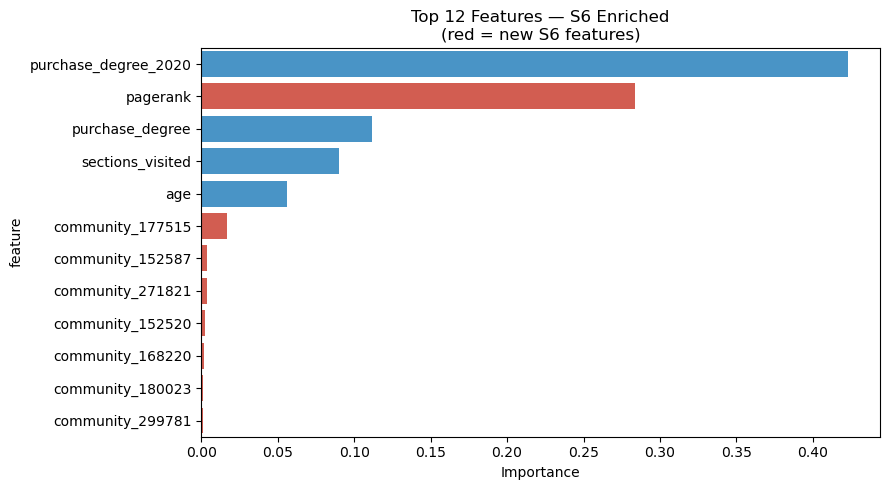

             feature  importance
purchase_degree_2020    0.422777
            pagerank    0.283422
     purchase_degree    0.111926
    sections_visited    0.090174
                 age    0.055809
    community_177515    0.016797
    community_152587    0.003690
    community_271821    0.003563
    community_152520    0.002636
    community_168220    0.001588
    community_180023    0.001146
    community_299781    0.001093

pagerank importance: 0.283422


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_names_e = list(
    pipeline_e.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features_e)
)
all_names_e   = numerical_features_e + cat_names_e
importances_e = pipeline_e.named_steps['classifier'].feature_importances_

feat_df_e = pd.DataFrame({'feature': all_names_e, 'importance': importances_e})
feat_df_e = feat_df_e.sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if 'pagerank' in f or 'community' in f
          else '#3498db' for f in feat_df_e['feature']]
sns.barplot(data=feat_df_e, x='importance', y='feature',hue='feature', palette=colors, legend=False)
plt.title('Top 12 Features — S6 Enriched\n(red = new S6 features)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(feat_df_e.to_string(index=False))

# Specifically check pagerank rank
pr_rank = feat_df_e[feat_df_e['feature'] == 'pagerank']
if not pr_rank.empty:
    print(f'\npagerank importance: {pr_rank["importance"].values[0]:.6f}')
else:
    print('\npagerank not in top 12 — very low importance')

## Cell 15 — Business Interpretation

### PageRank on Customer Nodes
The top-ranked customers by PageRank are those who purchased the same products as other high-PageRank customers — they sit at the structural centre of the H&M purchase network. These customers are connected to the most popular product hubs (basics, essentials) and their purchasing behaviour overlaps with many other active buyers. For the store manager, a high-PageRank customer is a strong candidate for loyalty programme targeting — they are embedded in the core of the purchase network and likely to respond to cross-category promotions.

### Louvain Communities on Customer Nodes
Louvain grouped customers into communities based on overlapping purchase histories. Customers in the same community bought similar sets of products. Inspecting the top communities by age band distribution reveals whether communities encode demographic purchasing personas (e.g. a community dominated by 20s customers likely represents a Young Fashion buyer cluster). If communities show no clear demographic pattern, they may still encode latent style preferences (sportswear vs occasionwear buyers) that are not visible in the node attributes alone. The community label as a model feature lets the classifier leverage these purchasing persona signals.

## Cell 16 — Save Enriched Model

In [16]:
joblib.dump(pipeline_e, MODELS_DIR / 'customer_value_classifier_s6.pkl')
print('Enriched model saved → customer_value_classifier_s6.pkl')
print('Session 7 Streamlit dashboard loads this model.')

Enriched model saved → customer_value_classifier_s6.pkl
Session 7 Streamlit dashboard loads this model.


---
## S6 Summary

| Item | Value |
|---|---|
| **Graph projected** | Customer + Article nodes, PURCHASED edges (UNDIRECTED) |
| **Node type** | Customer — same as S5 classifier unit |
| **node_id match** | customerId on both S5 matrix and GDS export — clean merge |
| **PageRank** | `writeProperty: 'pagerank'`, dampingFactor=0.85, maxIterations=20 |
| **Louvain** | `writeProperty: 'community'`, maxLevels=10 |
| **Merge** | `pd.merge(s5_matrix, gds_features, how='left', on='node_id')` |
| **NaN fill** | pagerank → 0.0, community → -1 |
| **New features** | `pagerank` (numerical) + `community` (categorical) |
| **Before/after** | See Cell 12 |
| **Saved model** | `customer_value_classifier_s6.pkl` |